<a href="https://colab.research.google.com/github/aniket9608/Machine_learning_practice/blob/main/campusX_funcTrans30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
# FUNCTION TRANSFORMATION  -MATHEMATICAL TRANSFORMATION

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier



In [2]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_1893/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [5]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [8]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [9]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,train_size=0.2,random_state=42)

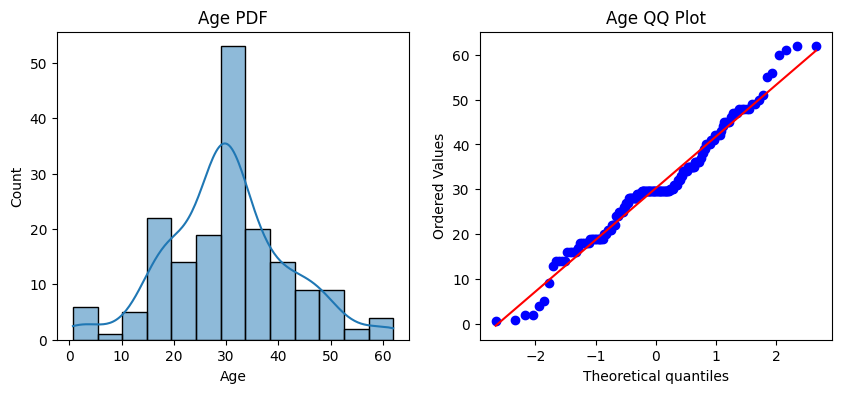

In [22]:
plt.figure(figsize=(10,4))
plt.subplot(121)
sns.histplot(X_train['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('Age QQ Plot')

plt.show()

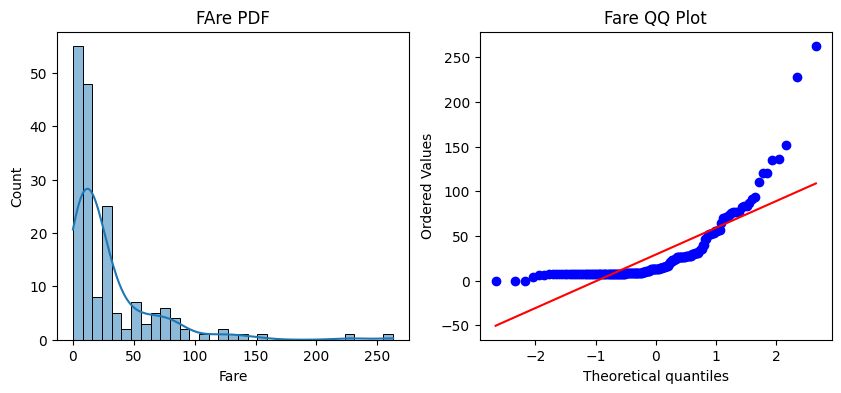

In [24]:
plt.figure(figsize=(10,4))
plt.subplot(121)
sns.histplot(X_train['Fare'],kde=True)
plt.title('FAre PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [35]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(X_train,Y_train)
clf2.fit(X_train,Y_train)
y_pred=clf.predict(X_test)
y_pred2=clf2.predict(X_test)

print(accuracy_score(Y_test,y_pred))
print(accuracy_score(Y_test,y_pred2))

0.6619915848527349
0.6185133239831697


In [36]:

# AFTER FUNCTION TRANSFORM


trf1=FunctionTransformer(func=np.log1p)


In [37]:
X_train_transformed=trf1.fit_transform(X_train)
X_test_transformed=trf1.fit_transform(X_test)

In [41]:
clf.fit(X_train_transformed,Y_train)
clf2.fit(X_train_transformed,Y_train)
y_pred=clf.predict(X_test_transformed)
y_pred2=clf2.predict(X_test_transformed)

print(accuracy_score(Y_test,y_pred))
print(accuracy_score(Y_test,y_pred2))

0.6746143057503506
0.6185133239831697


In [44]:
X_transformed = trf1.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6510112359550562


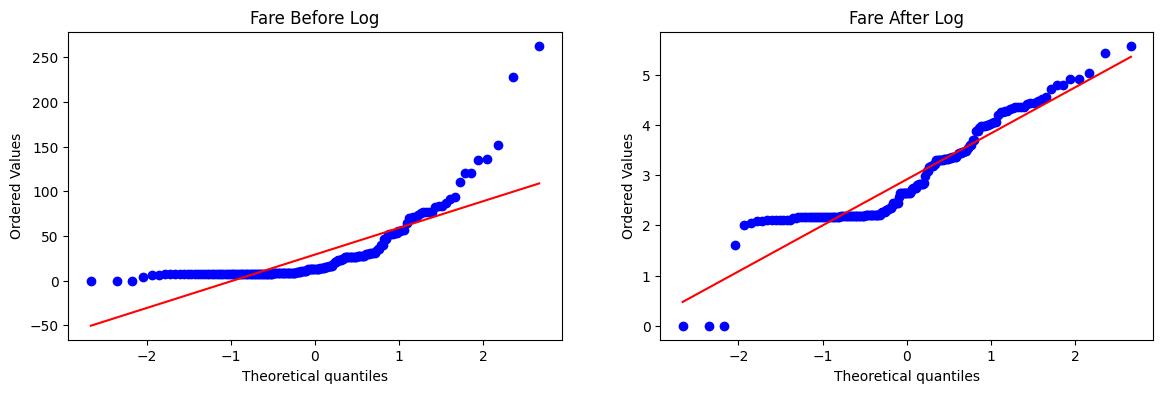

In [45]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()


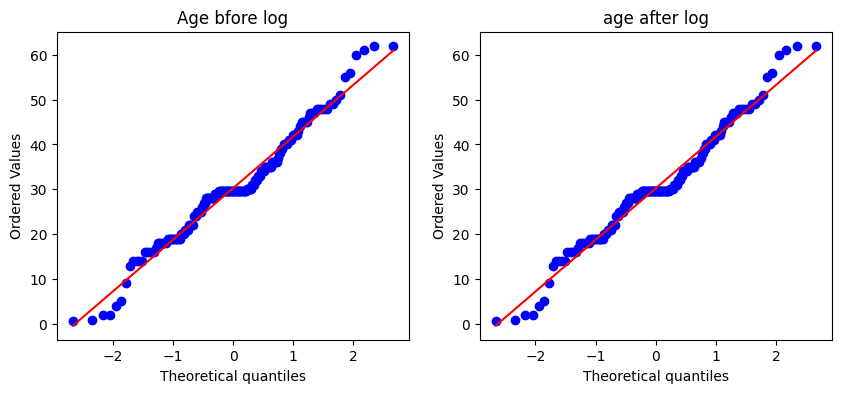

In [47]:
plt.figure(figsize=(10,4))

plt.subplot(121)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('Age bfore log')

plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('age after log')

plt.show()

In [48]:
# APPLYING FUNCTION TRANSFORM ONE COLUMN

trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [50]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,Y_train)
clf2.fit(X_train_transformed2,Y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(Y_test,y_pred))
print("Accuracy DT",accuracy_score(Y_test,y_pred2))


Accuracy LR 0.6788218793828892
Accuracy DT 0.6185133239831697


In [52]:
X_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))


LR 0.6712609238451936
DT 0.6655680399500625


In [53]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6195131086142323


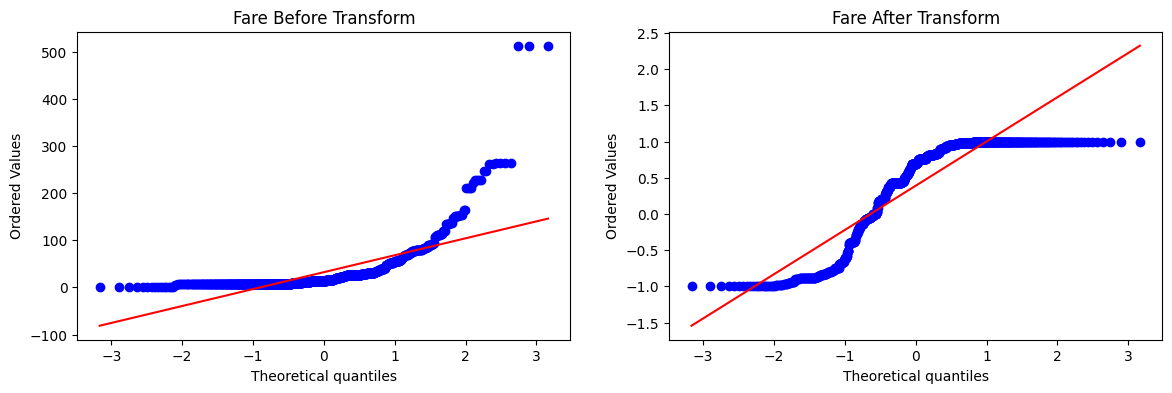

In [54]:
apply_transform(np.sin)